<a href="https://colab.research.google.com/github/bhalleaheesha/Data-Analyst-and-Data-Science-Projects/blob/main/Housing_Market_Price_Analysis_%26_Prediction_%5BData_Science_Project%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("/content/House Price India.csv")

In [4]:
print(df.head())

               date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  02-05-2014 00:00   313000.0         3       1.50         1340      7912   
1  02-05-2014 00:00  2384000.0         5       2.50         3650      9050   
2  02-05-2014 00:00   342000.0         3       2.00         1930     11947   
3  02-05-2014 00:00   420000.0         3       2.25         2000      8030   
4  02-05-2014 00:00   550000.0         4       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    street       city    

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   int64  
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [6]:
print(df.isnull().sum())

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [7]:
#Data Cleaning
# Drop unnecessary columns
df.drop(['street', 'country'], axis=1, inplace=True)

# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df.drop('date', axis=1, inplace=True)

# Fill missing values (if any)
df.fillna(df.median(numeric_only=True), inplace=True)

In [9]:
#Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['city'] = le.fit_transform(df['city'])
print("city:", df['city'].unique())

df['statezip'] = le.fit_transform(df['statezip'])
print("statezip:", df['statezip'].unique())

city: [4 5 8 6 0 9 2 1 3 7]
statezip: [3369 2445 1425 ... 4173  584 3904]


In [10]:
#Feature and Target Split
X = df.drop('price', axis=1)
y = df['price']

In [12]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

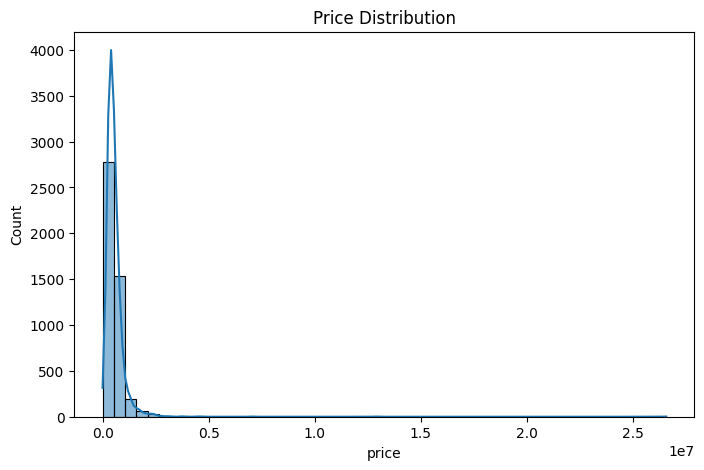

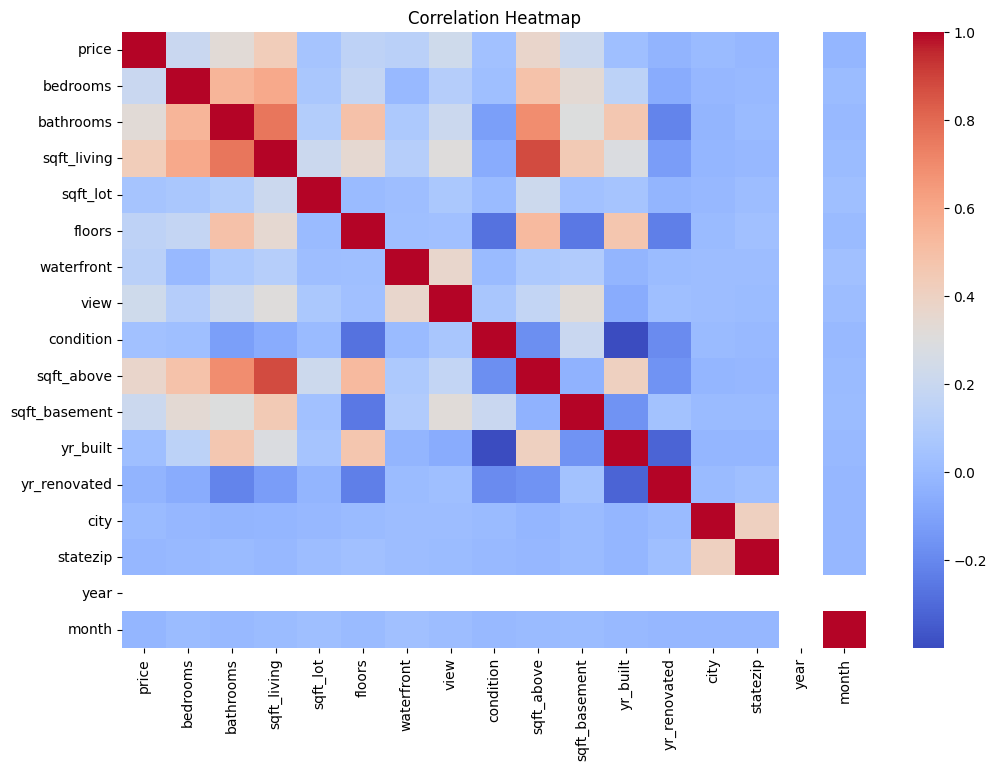

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
city             0.001217
statezip        -0.011794
month           -0.019874
yr_renovated    -0.028774
year                  NaN
Name: price, dtype: float64


In [13]:
#Exploratory Data Analysis (EDA)
# Price distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Top correlated features with price
corr = df.corr()['price'].sort_values(ascending=False)
print(corr)

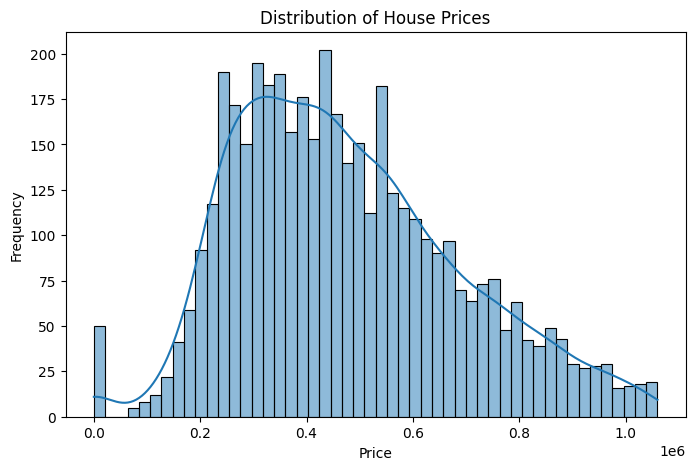

In [31]:
#Price Distribution (Understand Target Variable)
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

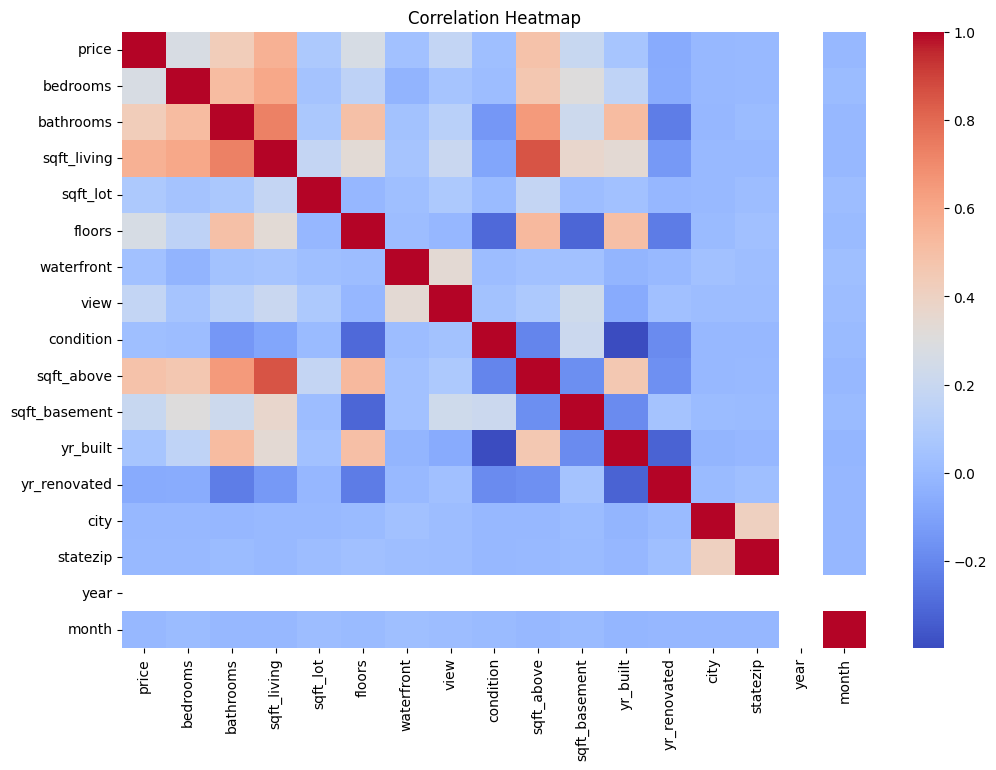

In [32]:
#Feature Relationships
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

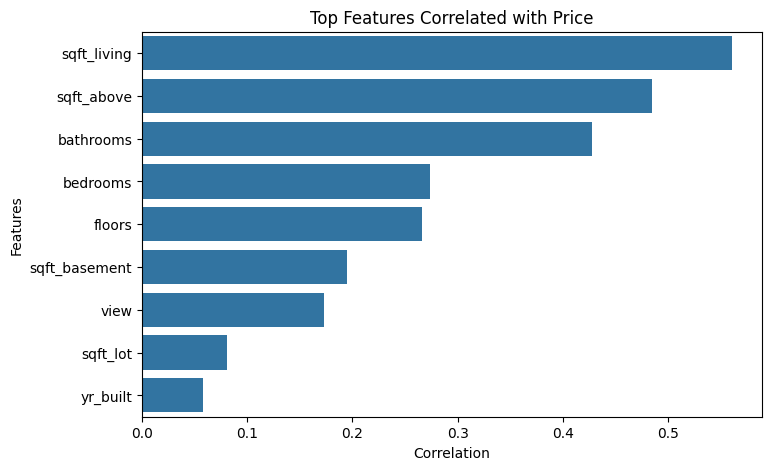

In [33]:
#Top Features vs Price
corr = df.corr()['price'].sort_values(ascending=False)[1:10]

plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Top Features Correlated with Price")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

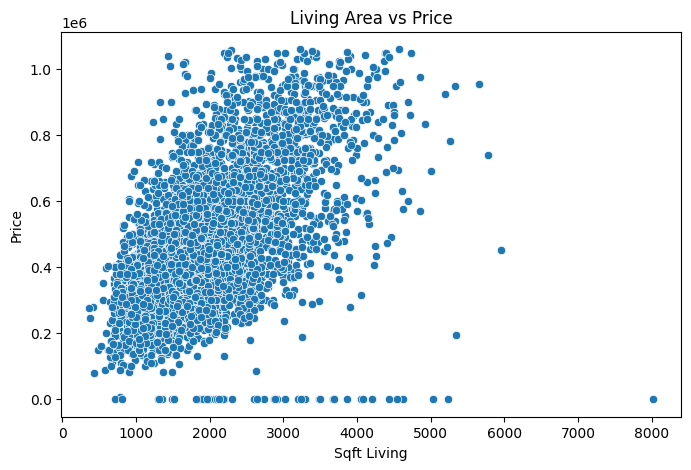

In [34]:
#Living Area vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['sqft_living'], y=df['price'])
plt.title("Living Area vs Price")
plt.xlabel("Sqft Living")
plt.ylabel("Price")
plt.show()

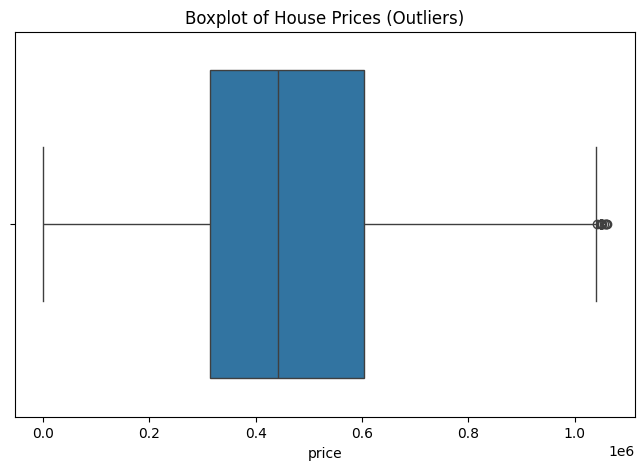

In [35]:
#Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(x=df['price'])
plt.title("Boxplot of House Prices (Outliers)")
plt.show()

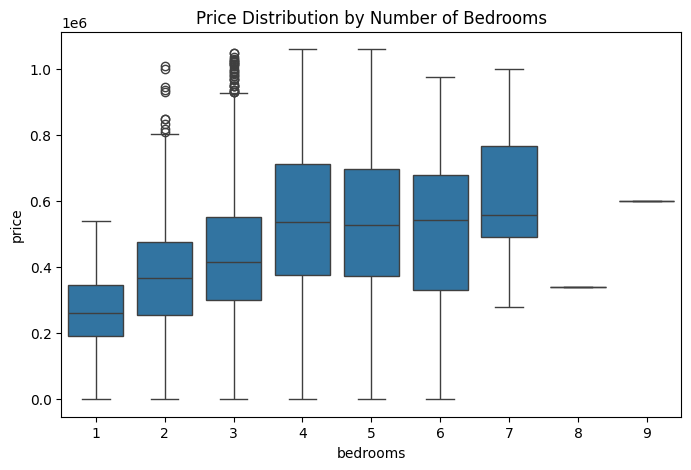

In [36]:
#Price by Bedrooms
plt.figure(figsize=(8,5))
sns.boxplot(x=df['bedrooms'], y=df['price'])
plt.title("Price Distribution by Number of Bedrooms")
plt.show()

In [16]:
#Outlier Handling
# Remove extreme outliers using IQR

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['price'] >= Q1 - 1.5*IQR) & (df['price'] <= Q3 + 1.5*IQR)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("New shape:", df.shape)
print(df.head())

Q1: 315000.0
Q3: 613000.0
IQR: 298000.0
New shape: (4307, 17)
      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0  313000.0         3       1.50         1340      7912     1.5           0   
2  342000.0         3       2.00         1930     11947     1.0           0   
3  420000.0         3       2.25         2000      8030     1.0           0   
4  550000.0         4       2.50         1940     10500     1.0           0   
5  490000.0         2       1.00          880      6380     1.0           0   

   view  condition  sqft_above  sqft_basement  yr_built  yr_renovated  city  \
0     0          3        1340              0      1955          2005     4   
2     0          4        1930              0      1966             0     8   
3     0          4        1000           1000      1963             0     6   
4     0          4        1140            800      1976          1992     0   
5     0          3         880              0      1938          199

In [17]:
#Feature Scaling (for some models)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])   #prints first 5 rows

[[-0.44112227 -0.84320364 -0.82997105 -0.19343402 -0.02241648 -0.08500441
  -0.30919434 -0.6671122  -0.56522378 -0.67246372 -0.53101376  1.22167046
  -0.17496427  0.8077071   0.         -2.12680126]
 [ 1.75970468  0.43280154  1.56852826 -0.16171766  0.90655464 -0.08500441
   4.83007931  2.28641631  1.78955903 -0.06912828 -1.67469295 -0.82569345
   0.17269692  0.11153114  0.         -2.12680126]
 [-0.44112227 -0.20520105 -0.21736733 -0.0809775  -0.9513876  -0.08500441
  -0.30919434  0.80965205  0.11917123 -0.67246372 -0.1609999  -0.82569345
   1.21568049 -0.65697479  0.         -2.12680126]
 [-0.44112227  0.11380024 -0.14468553 -0.19014533 -0.9513876  -0.08500441
  -0.30919434  0.80965205 -0.9596209   1.48230571 -0.26191277 -0.82569345
   0.52035811  1.39689498  0.         -2.12680126]
 [ 0.6592912   0.43280154 -0.20698422 -0.12130577 -0.9513876  -0.08500441
  -0.30919434  0.80965205 -0.79722209  1.05135182  0.17537633  1.20839578
  -1.56560904 -1.27630016  0.         -2.12680126]]


In [23]:
#Model Training
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
#Prediction
y_pred = model.predict(X_test)

In [18]:
#Train-Test Split (Scaled)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [20]:
#Multiple Models Comparison
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    results[name] = r2

print("Model Comparison:")
for k, v in results.items():
    print(f"{k}: {v}")

Model Comparison:
Linear Regression: 0.031886012047769974
Decision Tree: -0.01670414807861098
Random Forest: 0.03475906081641522


In [21]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


In [22]:
#Cross Validation Score
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='r2')

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", np.mean(cv_scores))

Cross Validation Scores: [ 0.41396727  0.28757082  0.45859845 -0.52934585  0.01411191]
Average CV Score: 0.1289805182894866


In [25]:
#Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Performance:
MAE : 205866.37706475542
MSE : 987742802937.0592
RMSE: 993852.5056249842
R2 Score: 0.03147879821491839


          Feature  Importance
2     sqft_living    0.529083
10       yr_built    0.084814
3        sqft_lot    0.064797
8      sqft_above    0.057390
13       statezip    0.053859
9   sqft_basement    0.043057
1       bathrooms    0.033893
6            view    0.029161
15          month    0.020109
12           city    0.019627
0        bedrooms    0.015934
11   yr_renovated    0.015915
7       condition    0.015755
4          floors    0.010385
5      waterfront    0.006222
14           year    0.000000


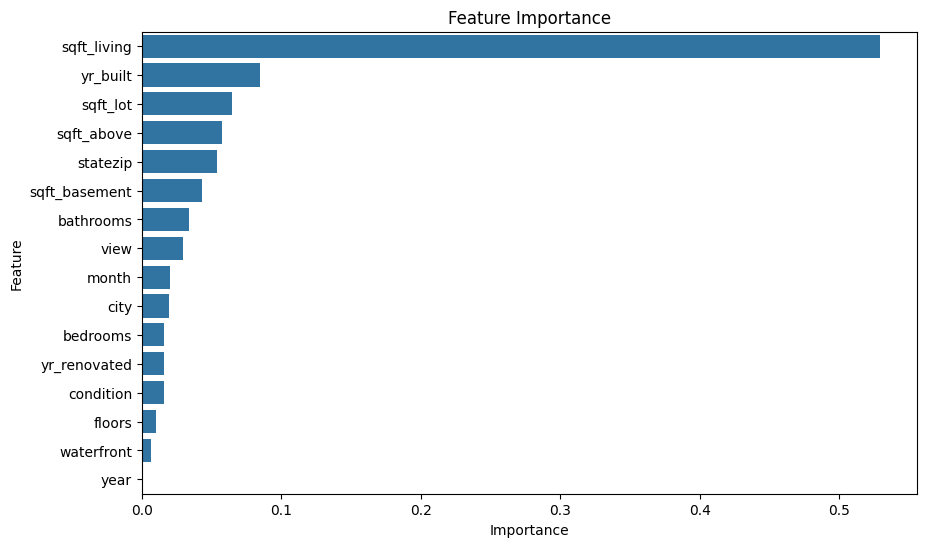

In [26]:
#Feature Importance
importances = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Feature Importance")
plt.show()

In [27]:
#Final Model Evaluation
y_pred = best_model.predict(X_test)

print("Final R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Final R2 Score: 0.03130483796068251
MAE: 206787.35988960628
RMSE: 993941.7566767492


In [28]:
#Save Model
import joblib

joblib.dump(best_model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [29]:
#For Implementing and Loading Model Later
model = joblib.load("house_price_model.pkl")
scaler = joblib.load("scaler.pkl")